# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [13]:
df = pd.read_csv('../data/checker_submits.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df = df[['uid', 'labname', 'numTrials', 'hour', 'dayofweek']]
categorical_cols = ['uid', 'labname']
ohe = OneHotEncoder(sparse=False)
encoded_cat = ohe.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded_cat, columns=ohe.get_feature_names(categorical_cols))
df = df.drop(columns=categorical_cols).reset_index(drop=True)
df = pd.concat([df, encoded_df], axis=1)
scaler = StandardScaler()
df[['numTrials', 'hour']] = scaler.fit_transform(df[['numTrials', 'hour']])
df.to_csv('../data/dayofweek.csv', index=False)
most_popular_class = df['dayofweek'].mode()[0]
naive_predictions = [most_popular_class] * len(df)
accuracy_naive = accuracy_score(df['dayofweek'], naive_predictions)
print(f'Accuracy of naive classifier (predicting class {most_popular_class}): {accuracy_naive:}')

Accuracy of naive classifier (predicting class 3): 0.23487544483985764


In [14]:
df

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,-0.788667,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.756764,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.724861,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.692958,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.661055,-2.562352,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,-0.533442,0.945382,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1682,-0.629151,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1683,-0.597248,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,-0.565345,0.945382,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

Accuracy of logistic regression baseline model: 0.6216


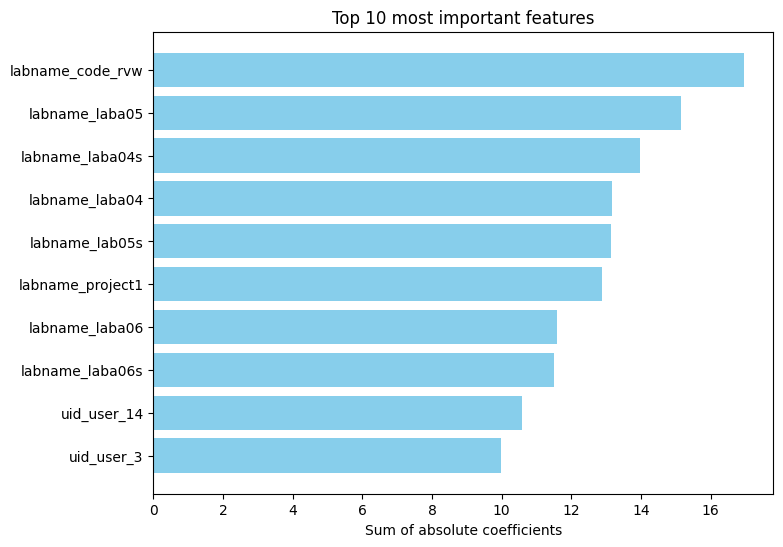

In [15]:
X = df.drop(columns=['dayofweek'])
y = df['dayofweek']

clf = LogisticRegression(random_state=21, fit_intercept=False, solver='liblinear')
clf.fit(X, y)

y_pred = clf.predict(X)
acc = accuracy_score(y, y_pred)
print(f'Accuracy of logistic regression baseline model: {acc:.4f}')

def plot_top_features(coefs, feature_names, top_n=10):
    importances = np.sum(np.abs(coefs), axis=0)
    top_indices = np.argsort(importances)[-top_n:][::-1]
    top_features = [feature_names[i] for i in top_indices]
    top_importances = importances[top_indices]
    plt.figure(figsize=(8, 6))
    plt.barh(top_features, top_importances, color='skyblue')
    plt.xlabel('Sum of absolute coefficients')
    plt.title(f'Top {top_n} most important features')
    plt.gca().invert_yaxis()
    plt.show()

feature_names = X.columns.tolist()
plot_top_features(clf.coef_, feature_names, top_n=10)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

Accuracy (linear kernel): 0.6120996441281139
Accuracies for different kernels: {'linear': 0.6120996441281139, 'poly': 0.8653618030842231, 'rbf': 0.8641755634638197, 'sigmoid': 0.3499406880189798}


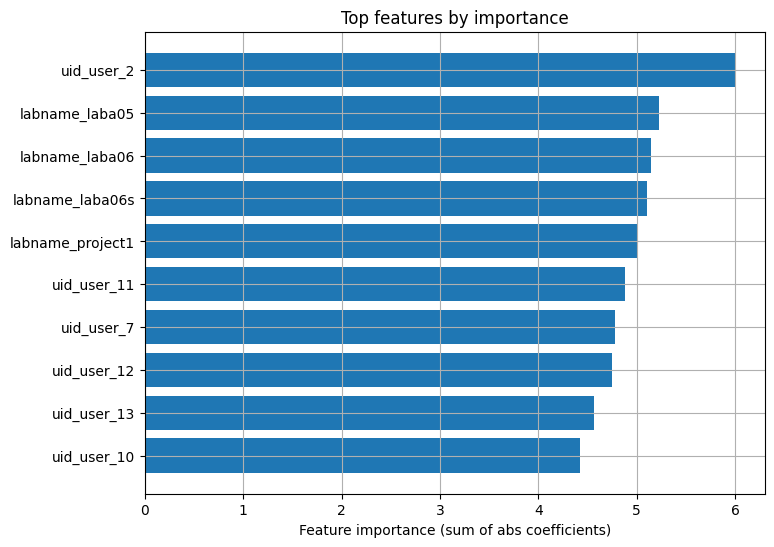

In [16]:
X = df.drop('dayofweek', axis=1)
y = df['dayofweek']

svc_linear = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=21))
svc_linear.fit(X, y)

y_pred_linear = svc_linear.predict(X)
acc_linear = accuracy_score(y, y_pred_linear)
print(f'Accuracy (linear kernel): {acc_linear:}')

kernels = ['poly', 'rbf', 'sigmoid']
accuracies = {'linear': acc_linear}
for kernel in kernels:
    svc = OneVsRestClassifier(SVC(kernel=kernel, probability=True, random_state=21))
    svc.fit(X, y)
    y_pred = svc.predict(X)
    acc = accuracy_score(y, y_pred)
    accuracies[kernel] = acc
print('Accuracies for different kernels:', accuracies)

def plot_top_features(coefs, feature_names, top_n=10):
    importance = np.sum(np.abs(coefs), axis=0)
    top_indices = np.argsort(importance)[-top_n:][::-1]
    top_features = [feature_names[i] for i in top_indices]
    top_importance = importance[top_indices]

    plt.figure(figsize=(8, 6))
    plt.barh(top_features[::-1], top_importance[::-1])
    plt.xlabel('Feature importance (sum of abs coefficients)')
    plt.title('Top features by importance')
    plt.grid(True)
    plt.show()

feature_names = X.columns.to_list()

coefs_list = [est.coef_.ravel() for est in svc_linear.estimators_]
coefs_linear = np.vstack(coefs_list)

plot_top_features(coefs_linear, feature_names, top_n=10)

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

Accuracy baseline (max_depth=4): 0.5516014234875445


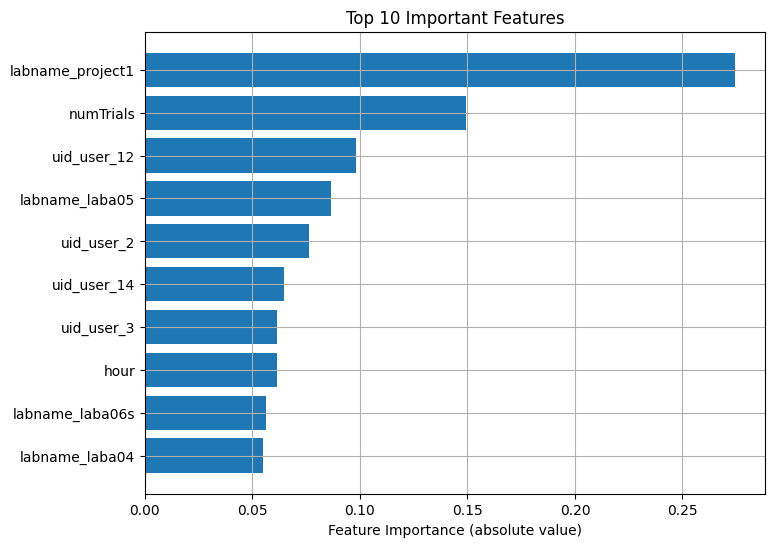

In [17]:

dt_baseline = DecisionTreeClassifier(max_depth=4, random_state=21)
dt_baseline.fit(X, y)
y_pred_baseline = dt_baseline.predict(X)
accuracy_baseline = accuracy_score(y, y_pred_baseline)
print(f"Accuracy baseline (max_depth=4): {accuracy_baseline:}")

depths = range(1, 15)
accuracies = []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=21)
    dt.fit(X, y)
    y_pred = dt.predict(X)
    acc = accuracy_score(y, y_pred)
    accuracies.append(acc)
    
def plot_top_features(importances, feature_names, top_n=10):
    indices = np.argsort(np.abs(importances))[-top_n:][::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(range(top_n), importances[indices][::-1], align='center')
    plt.yticks(range(top_n), [feature_names[i] for i in indices][::-1])
    plt.xlabel('Feature Importance (absolute value)')
    plt.title(f'Top {top_n} Important Features')
    plt.grid(True)
    plt.show()

plot_top_features(dt_baseline.feature_importances_, X.columns, top_n=10)

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

Baseline RandomForest accuracy (n_estimators=100, max_depth=25): 1.0000
    max_depth  n_estimators  accuracy
0           5            10  0.603203
1           5            50  0.584816
2           5           100  0.579478
3           5           200  0.585409
4          10            10  0.828588
5          10            50  0.870107
6          10           100  0.885528
7          10           200  0.877817
8          15            10  0.964413
9          15            50  0.978648
10         15           100  0.978055
11         15           200  0.979241
12         20            10  0.983986
13         20            50  0.997034
14         20           100  0.996441
15         20           200  0.996441
16         25            10  0.995848
17         25            50  1.000000
18         25           100  1.000000
19         25           200  1.000000
20         30            10  0.998221
21         30            50  1.000000
22         30           100  1.000000
23         30   

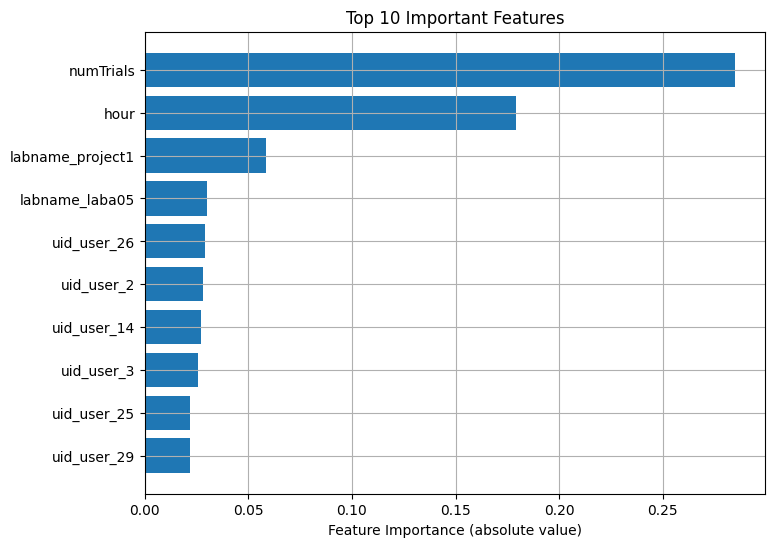

In [18]:

rf_baseline = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
rf_baseline.fit(X, y)
y_pred_baseline = rf_baseline.predict(X)
accuracy_baseline = accuracy_score(y, y_pred_baseline)
print(f"Baseline RandomForest accuracy (n_estimators=100, max_depth=25): {accuracy_baseline:.4f}")

depths = [5, 10, 15, 20, 25, 30]
estimators = [10, 50, 100, 200]
results = []

for d in depths:
    for n in estimators:
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=21)
        rf.fit(X, y)
        y_pred = rf.predict(X)
        acc = accuracy_score(y, y_pred)
        results.append({'max_depth': d, 'n_estimators': n, 'accuracy': acc})

df_results = pd.DataFrame(results)
print(df_results)

pivot_table = df_results.pivot(index='max_depth', columns='n_estimators', values='accuracy')
print(pivot_table)

def plot_top_features(importances, feature_names, top_n=10):
    indices = np.argsort(np.abs(importances))[-top_n:][::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(range(top_n), importances[indices][::-1], align='center')
    plt.yticks(range(top_n), [feature_names[i] for i in indices][::-1])
    plt.xlabel('Feature Importance (absolute value)')
    plt.title(f'Top {top_n} Important Features')
    plt.grid(True)
    plt.show()

plot_top_features(rf_baseline.feature_importances_, X.columns, top_n=10)